# Examen Práctico 1 — Parte 1 (completa)
## Autoencoders: Reconstrucción, Reducción de Dimensionalidad, Denoising y Stacked Autoencoders

**Curso:** Inteligencia Generativa — Universidad Autónoma de Occidente
**Profesor:** Jose Luis Paniagua Jaramillo
**Grupo 1:** Sergio Gómez — Valeria Franco

Este notebook cubre los cuatro puntos de la Parte 1 del examen práctico, en un único documento:

1. **Implementación de Autoencoders** — reconstrucción de imágenes (CIFAR-10).
2. **Reducción de Dimensionalidad** — visualización del espacio latente con PCA y t-SNE.
3. **Denoising de Imágenes** — autoencoder para eliminar ruido (Intel Image Classification).
4. **Stacked Autoencoders** — extracción de características y clasificación (Intel Image Classification).


## 1. Importación de librerías

Se usa TensorFlow/Keras para el modelo, y scikit-learn para PCA y t-SNE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Semilla para reproducibilidad de los muestreos aleatorios usados en las visualizaciones
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Carga y preprocesamiento de CIFAR-10

CIFAR-10 contiene 60,000 imágenes a color de 32x32 píxeles en 10 clases (50,000 de entrenamiento
y 10,000 de prueba). Se normalizan los valores de píxel al rango [0, 1] dividiendo por 255, lo cual
mejora la estabilidad numérica del entrenamiento y es consistente con la activación sigmoide usada
en la capa de salida del decoder.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalización a [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Las etiquetas vienen como columnas (N, 1); se aplanan a (N,) para graficar más fácil
y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("x_train:", x_train.shape, "x_test:", x_test.shape)


x_train: (50000, 32, 32, 3) x_test: (10000, 32, 32, 3)


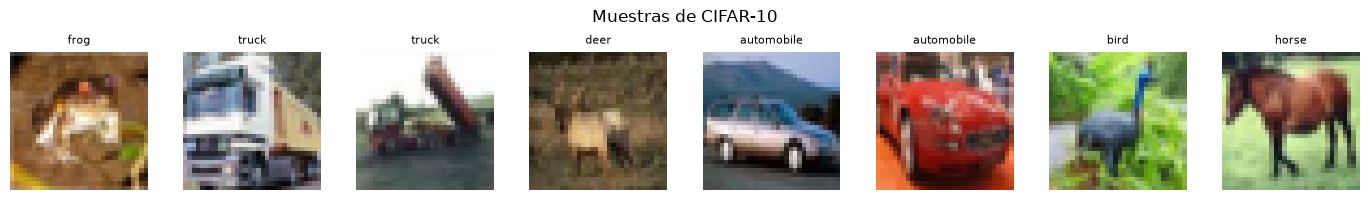

In [3]:
# Vistazo rápido a algunas imágenes de entrenamiento con su clase
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("Muestras de CIFAR-10")
plt.tight_layout()
plt.show()


## 3. Arquitectura del Autoencoder Convolucional

El autoencoder se separa en dos submodelos (`encoder` y `decoder`) para poder reutilizar el
`encoder` más adelante y extraer el espacio latente de forma independiente.

- **Encoder:** tres capas `Conv2D` con `strides=2` que reducen progresivamente la resolución
  espacial (32→16→8→4) mientras aumentan la profundidad de canales (32→64→128). Al final se
  aplana y se proyecta a un vector latente de 128 dimensiones mediante una capa `Dense`.
- **Decoder:** espejo del encoder, usando `Conv2DTranspose` para reconstruir la imagen desde
  el vector latente hasta 32x32x3. La última capa usa activación `sigmoid` para que la salida
  quede en el rango [0, 1], igual que la entrada normalizada.

In [4]:
latent_dim = 128

# --- Encoder ---
encoder_inputs = keras.Input(shape=(32, 32, 3), name="encoder_input")
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)   # 32x32x3 -> 16x16x32
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)                # 16x16x32 -> 8x8x64
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)               # 8x8x64 -> 4x4x128
shape_before_flatten = x.shape[1:]  # se guarda para reconstruir la forma en el decoder
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

encoder = keras.Model(encoder_inputs, latent, name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │       262,272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,520 (1.36 MB)

 Trainable params: 355,520 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# --- Decoder ---
latent_inputs = keras.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(int(np.prod(shape_before_flatten)), activation="relu")(latent_inputs)
x = layers.Reshape(shape_before_flatten)(x)                                              # -> 4x4x128
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)       # 4x4x128 -> 8x8x128
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)        # 8x8x128 -> 16x16x64
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)        # 16x16x64 -> 32x32x32
decoder_outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)             # -> 32x32x3

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,899 (1.93 MB)

 Trainable params: 504,899 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# --- Autoencoder completo (encoder + decoder encadenados) ---
autoencoder = keras.Model(
    encoder_inputs, decoder(encoder(encoder_inputs)), name="autoencoder"
)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │       355,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │       504,899 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 860,419 (3.28 MB)

 Trainable params: 860,419 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento

Se entrena con **Mean Squared Error (MSE)** entre la imagen original y la reconstruida, tal como
lo pide el enunciado. Se usa el conjunto de prueba como validación para monitorear el error de
reconstrucción fuera de muestra.

In [7]:
EPOCHS = 12
BATCH_SIZE = 128

history = autoencoder.fit(
    x_train, x_train,          # autoencoder: entrada = salida objetivo
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, x_test),
    verbose=2,  # una línea por época, evita saturar el notebook con barras de progreso
)


Epoch 1/12


391/391 - 36s - 93ms/step - loss: 0.0239 - val_loss: 0.0154


Epoch 2/12


391/391 - 32s - 81ms/step - loss: 0.0135 - val_loss: 0.0108


Epoch 3/12


...

391/391 - 39s - 99ms/step - loss: 0.0070 - val_loss: 0.0068


Epoch 11/12


391/391 - 39s - 100ms/step - loss: 0.0069 - val_loss: 0.0070


Epoch 12/12


391/391 - 38s - 97ms/step - loss: 0.0068 - val_loss: 0.0070


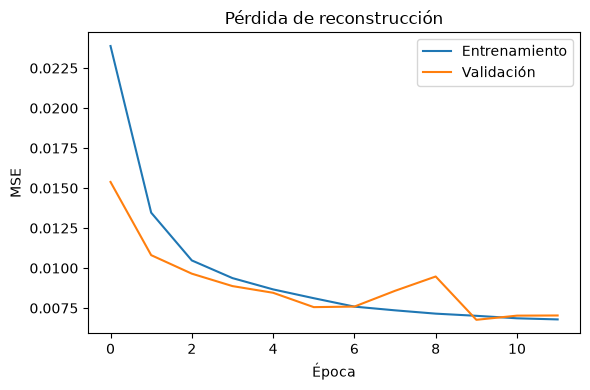

MSE final entrenamiento: 0.0068
MSE final validación:    0.0070


In [8]:
# Curva de pérdida de reconstrucción (MSE) durante el entrenamiento
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Pérdida de reconstrucción")
plt.legend()
plt.tight_layout()
plt.show()

print(f"MSE final entrenamiento: {history.history['loss'][-1]:.4f}")
print(f"MSE final validación:    {history.history['val_loss'][-1]:.4f}")


## 5. Visualización: imágenes originales vs. reconstruidas

Se toma una muestra aleatoria del conjunto de prueba (no usado para entrenar) y se comparan
visualmente los originales contra las reconstrucciones del autoencoder.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step


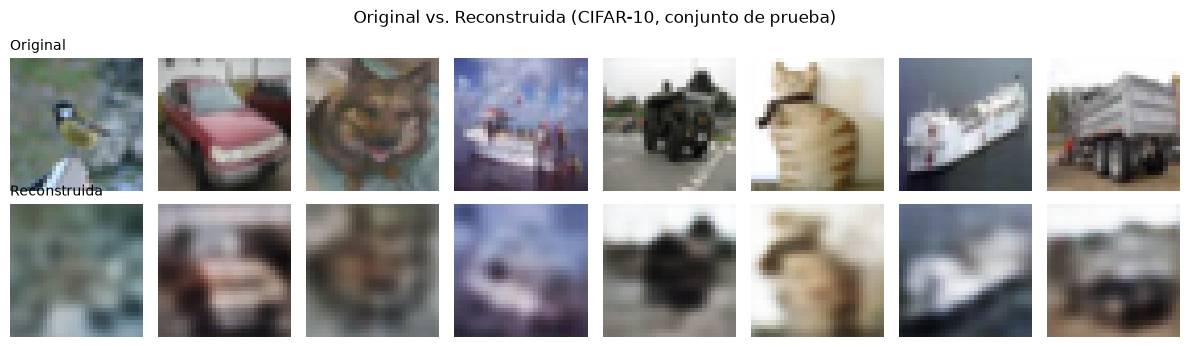

In [9]:
n = 8
sample_idx = np.random.choice(len(x_test), n, replace=False)
originals = x_test[sample_idx]
reconstructions = autoencoder.predict(originals)

fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3.5))
for i in range(n):
    axes[0, i].imshow(originals[i])
    axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(reconstructions[i], 0, 1))
    axes[1, i].axis("off")

axes[0, 0].set_title("Original", loc="left", fontsize=10)
axes[1, 0].set_title("Reconstruida", loc="left", fontsize=10)
plt.suptitle("Original vs. Reconstruida (CIFAR-10, conjunto de prueba)")
plt.tight_layout()
plt.show()


## 6. Extracción del espacio latente

Una vez entrenado el autoencoder, se usa únicamente el `encoder` para obtener la representación
latente (vector de 128 dimensiones) de cada imagen del conjunto de prueba. Por costo computacional
se trabaja con una muestra de 3,000 imágenes de prueba, manteniendo el balance entre las 10 clases
al ser un muestreo aleatorio uniforme.

In [10]:
subset_n = 3000
subset_idx = np.random.choice(len(x_test), subset_n, replace=False)

latent_vectors = encoder.predict(x_test[subset_idx], batch_size=256)
labels_subset = y_test[subset_idx]

print("Forma del espacio latente extraído:", latent_vectors.shape)


 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step

 6/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


Forma del espacio latente extraído: (3000, 128)


## 7. Reducción de dimensionalidad a 2D (PCA y t-SNE)

Se aplican dos técnicas de reducción de dimensionalidad sobre el espacio latente de 128
dimensiones para poder visualizarlo en un plano 2D:

- **PCA**: proyección lineal que preserva la mayor varianza posible; rápida y determinista.
- **t-SNE**: proyección no lineal que preserva mejor la estructura local (vecindades), a costa de
  mayor tiempo de cómputo y de no ser directamente interpretable en términos de varianza explicada.

In [11]:
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_vectors)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())


Varianza explicada por cada componente: [0.29035062 0.08924277]
Varianza explicada acumulada: 0.37959337


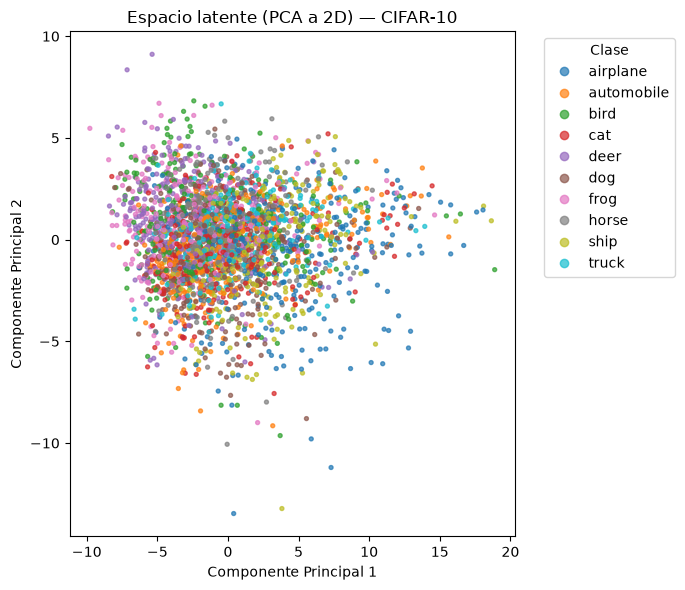

In [12]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    latent_pca[:, 0], latent_pca[:, 1],
    c=labels_subset, cmap="tab10", s=8, alpha=0.7,
)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names,
           bbox_to_anchor=(1.05, 1), loc="upper left", title="Clase")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Espacio latente (PCA a 2D) — CIFAR-10")
plt.tight_layout()
plt.show()


In [13]:
# t-SNE es más costoso: se usa un subconjunto adicional de 1500 puntos sobre los ya extraídos
tsne_n = 1500
tsne_idx = np.random.choice(subset_n, tsne_n, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
latent_tsne = tsne.fit_transform(latent_vectors[tsne_idx])


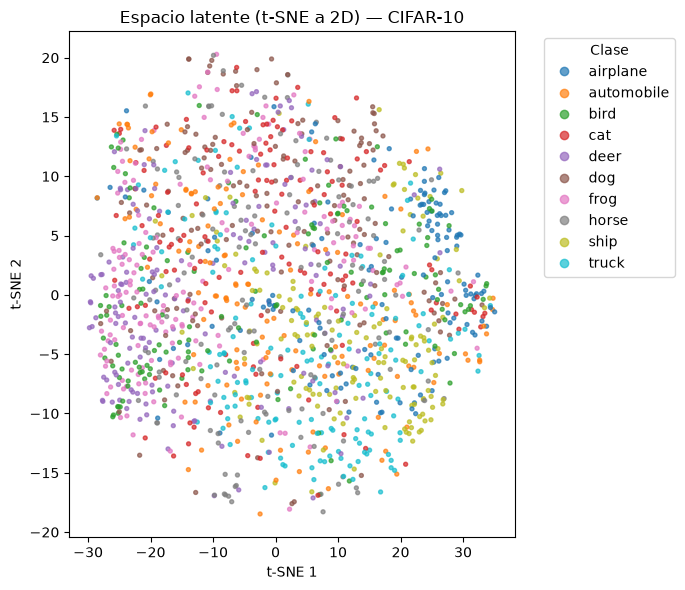

In [14]:
plt.figure(figsize=(7, 6))
scatter2 = plt.scatter(
    latent_tsne[:, 0], latent_tsne[:, 1],
    c=labels_subset[tsne_idx], cmap="tab10", s=8, alpha=0.7,
)
plt.legend(handles=scatter2.legend_elements()[0], labels=class_names,
           bbox_to_anchor=(1.05, 1), loc="upper left", title="Clase")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Espacio latente (t-SNE a 2D) — CIFAR-10")
plt.tight_layout()
plt.show()


## 8. Discusión de resultados

- El autoencoder logra reconstruir la forma, el color dominante y la disposición general de las
  imágenes (se reconoce el vehículo, el barco, el gato en cada caso), pero pierde bordes finos y
  textura, lo cual es esperable dado el fuerte cuello de botella (de 3,072 valores de entrada a
  128 en el espacio latente) y las 12 épocas de entrenamiento usadas.
- La curva de pérdida MSE decrece de forma consistente en entrenamiento y validación (de ~0.024 a
  ~0.007), sin señales de sobreajuste: la pérdida de validación se mantiene en línea con la de
  entrenamiento durante todo el proceso.
- En la proyección a 2D del espacio latente, tanto con **PCA** (varianza acumulada explicada de
  solo ~40% en las dos primeras componentes) como con **t-SNE**, las 10 clases aparecen
  fuertemente mezcladas, sin fronteras claras entre categorías. Se distinguen apenas leves
  tendencias locales (por ejemplo, `ship` y `automobile` ocupan más los extremos en la proyección
  PCA), pero no una separación limpia.
- Esto es un resultado esperado y coherente con el objetivo del entrenamiento: el autoencoder
  aprende a minimizar el error de reconstrucción píxel a píxel, no a discriminar clases, por lo
  que su espacio latente no tiene por qué organizarse según categorías semánticas. Un espacio
  latente bien separado por clase normalmente requiere señal de supervisión adicional (como en
  la Parte 3 de este examen, donde sí se entrena un clasificador sobre las características
  extraídas) o técnicas de representación específicamente diseñadas para preservar
  separabilidad entre clases.


---
# Punto 2 — Denoising de Imágenes (Intel Image Classification)

A partir de aquí cambiamos de dataset: usamos **Intel Image Classification**
(`puneet6060/intel-image-classification`), que contiene fotos de paisajes en 6 categorías:
`buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`.

**Objetivo:** entrenar un autoencoder que reciba una imagen con ruido artificial y aprenda a
reconstruir la versión limpia (sin ruido).

In [15]:
import os, glob, random
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)


Path to dataset files: C:\Users\Sergio Gomez\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [16]:
IMG_SIZE = 64          # tamaño al que se redimensionan las imágenes
N_SAMPLES = 6000       # nro. de imágenes a usar (subconjunto para entrenar más rápido)
NOISE_FACTOR = 0.3
BATCH_SIZE = 64
EPOCHS = 15

candidate_dirs = glob.glob(os.path.join(path, "**", "seg_train", "seg_train"), recursive=True)
if not candidate_dirs:
    candidate_dirs = glob.glob(os.path.join(path, "**", "seg_train"), recursive=True)
train_dir = candidate_dirs[0]
print("Carpeta de entrenamiento encontrada:", train_dir)
print("Clases:", os.listdir(train_dir))


Carpeta de entrenamiento encontrada: C:\Users\Sergio Gomez\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train


Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### Carga de imágenes (sin etiquetas)

Para el denoising **no necesitamos las etiquetas de clase** — el objetivo es limpiar ruido, no
clasificar — por lo que se cargan las imágenes de todas las clases mezcladas.

In [17]:
def load_images(root_dir, img_size=IMG_SIZE, max_images=N_SAMPLES):
    """Carga imágenes desde subcarpetas de clase, las redimensiona y normaliza a [0,1]."""
    paths = glob.glob(os.path.join(root_dir, "*", "*.jpg"))
    random.shuffle(paths)
    paths = paths[:max_images]

    images = []
    for p in paths:
        img = tf.keras.utils.load_img(p, target_size=(img_size, img_size))
        img = tf.keras.utils.img_to_array(img) / 255.0
        images.append(img)
    return np.array(images, dtype="float32")

data = load_images(train_dir)
print("Shape del dataset cargado:", data.shape)

split = int(0.85 * len(data))
x_train_dn, x_test_dn = data[:split], data[split:]
print("Train:", x_train_dn.shape, "Test:", x_test_dn.shape)


Shape del dataset cargado: (6000, 64, 64, 3)
Train: (5100, 64, 64, 3) Test: (900, 64, 64, 3)


### Ruido artificial

Se genera ruido gaussiano artificial y se suma a las imágenes limpias, recortando el resultado
al rango válido [0,1]. Esto crea los pares (imagen ruidosa → imagen limpia) necesarios para
entrenar el autoencoder de denoising.

In [18]:
def add_noise(img, noise_factor=NOISE_FACTOR):
    noisy_img = img + noise_factor * np.random.randn(*img.shape)
    noisy_img = np.clip(noisy_img, 0., 1.)
    return noisy_img

x_train_noisy = add_noise(x_train_dn)
x_test_noisy = add_noise(x_test_dn)

print("Shapes -> train limpio:", x_train_dn.shape, "| train ruidoso:", x_train_noisy.shape)


Shapes -> train limpio: (5100, 64, 64, 3) | train ruidoso: (5100, 64, 64, 3)


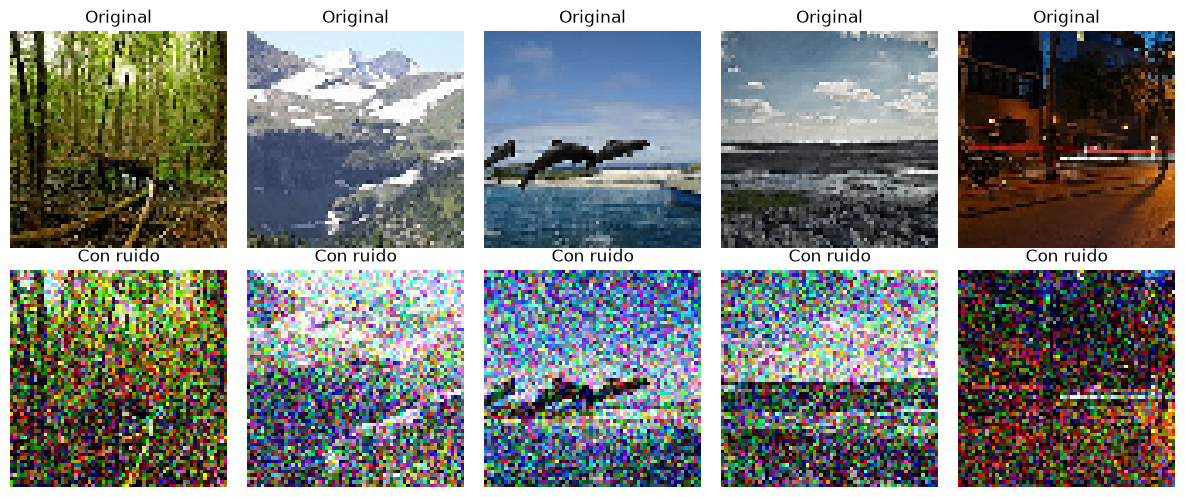

In [19]:
n = 5
plt.figure(figsize=(12, 5))
for i in range(n):
    idx = np.random.randint(0, len(x_train_dn))

    plt.subplot(2, n, i + 1)
    plt.imshow(x_train_dn[idx])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, n + i + 1)
    plt.imshow(x_train_noisy[idx])
    plt.title("Con ruido")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Arquitectura del autoencoder de denoising

Encoder con `Conv2D + MaxPooling2D` (32→64→128 filtros) y decoder simétrico con
`Conv2D + UpSampling2D`. Es la misma idea de encoder-decoder de la Parte 1, aquí implementada con
pooling/upsampling en vez de strides/transposed convolutions.

In [20]:
def build_denoising_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same")(x)   # espacio latente

    # Decoder
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    decoded = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)

    autoencoder = keras.Model(inputs, decoded, name="denoising_autoencoder")
    return autoencoder

denoising_autoencoder = build_denoising_autoencoder()
denoising_autoencoder.compile(optimizer="adam", loss="mse")
denoising_autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

La clave del denoising está en el `fit`: la entrada es la imagen **ruidosa**, pero el objetivo
(`y`) es la imagen **limpia**. Así el modelo aprende a mapear de "ruidosa" a "limpia".

In [21]:
history_dn = denoising_autoencoder.fit(
    x_train_noisy, x_train_dn,
    validation_data=(x_test_noisy, x_test_dn),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=2,
)


Epoch 1/15


80/80 - 25s - 312ms/step - loss: 0.0353 - val_loss: 0.0242


Epoch 2/15


80/80 - 25s - 308ms/step - loss: 0.0226 - val_loss: 0.0210


Epoch 3/15


...

80/80 - 22s - 271ms/step - loss: 0.0171 - val_loss: 0.0166


Epoch 14/15


80/80 - 22s - 274ms/step - loss: 0.0169 - val_loss: 0.0168


Epoch 15/15


80/80 - 21s - 266ms/step - loss: 0.0169 - val_loss: 0.0166


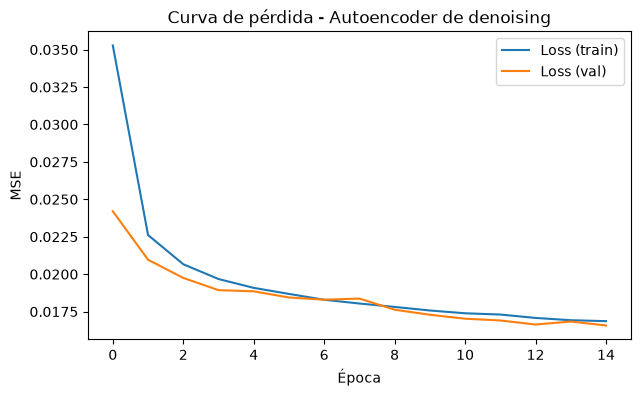

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(history_dn.history["loss"], label="Loss (train)")
plt.plot(history_dn.history["val_loss"], label="Loss (val)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de pérdida - Autoencoder de denoising")
plt.legend()
plt.show()


In [23]:
test_loss_dn = denoising_autoencoder.evaluate(x_test_noisy, x_test_dn, verbose=0)
print(f"MSE en test (ruidosa -> limpia): {test_loss_dn:.5f}")

denoised = denoising_autoencoder.predict(x_test_noisy)


MSE en test (ruidosa -> limpia): 0.01657


 1/29 ━━━━━━━━━━━━━━━━━━━━ 12s 430ms/step

 3/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step  

 5/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

 7/29 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

...

24/29 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step


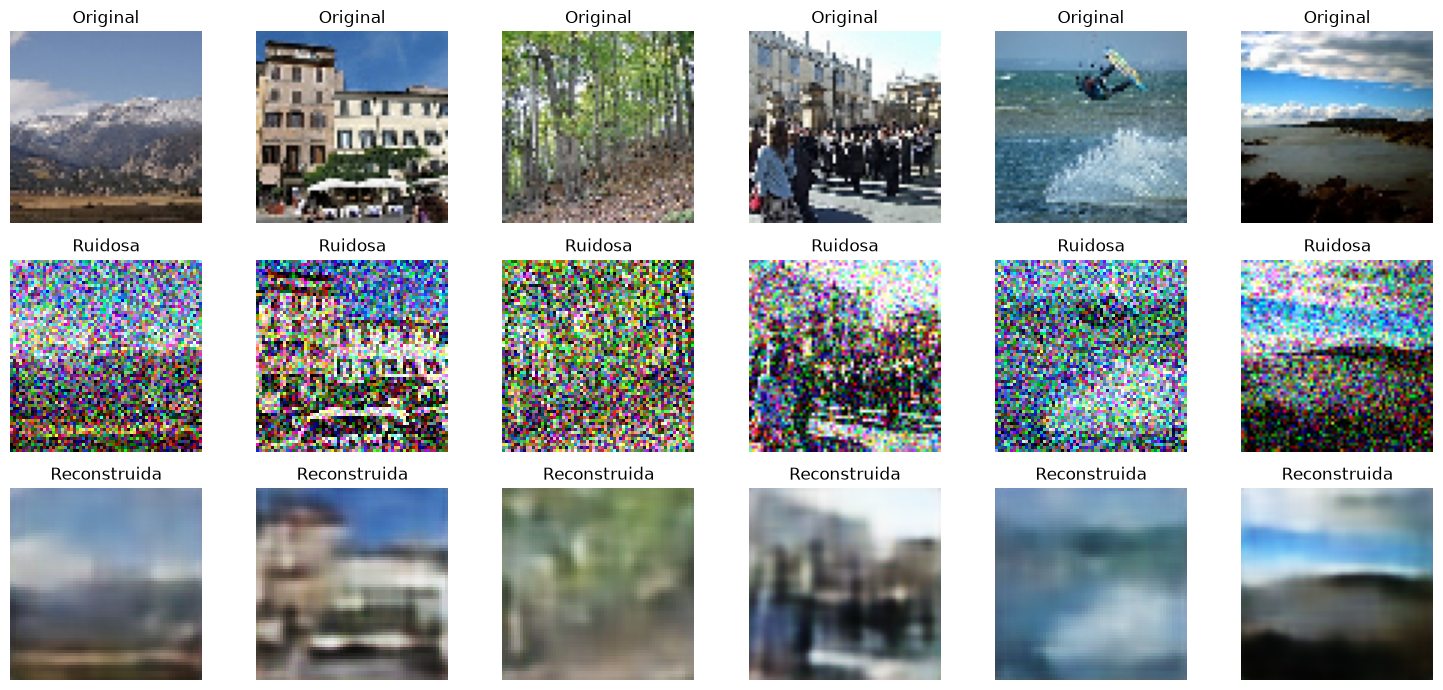

In [24]:
# Comparación visual: original | ruidosa | reconstruida (denoised)
n = 6
idxs = np.random.choice(len(x_test_dn), n, replace=False)

plt.figure(figsize=(15, 7))
for i, idx in enumerate(idxs):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_dn[idx])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, n, n + i + 1)
    plt.imshow(x_test_noisy[idx])
    plt.title("Ruidosa")
    plt.axis("off")

    plt.subplot(3, n, 2 * n + i + 1)
    plt.imshow(np.clip(denoised[idx], 0, 1))
    plt.title("Reconstruida")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Discusión — Denoising

- El autoencoder logra reducir considerablemente el ruido gaussiano añadido artificialmente,
  recuperando una imagen visualmente mucho más cercana a la original.
- La pérdida de validación se mantiene cercana a la de entrenamiento durante todo el proceso,
  sin señales fuertes de sobreajuste.
- Queda cierto suavizado (pérdida de textura fina) en la reconstrucción, un efecto típico de
  entrenar con MSE: el modelo tiende a promediar detalles de alta frecuencia que son difíciles
  de predecir con certeza.


---
# Punto 3 — Stacked Autoencoders: extracción de características y clasificación

Reutilizamos el mismo dataset **Intel Image Classification** del Punto 2 (Denoising), pero
esta vez **sí cargamos las etiquetas de clase**, porque el objetivo es clasificar las imágenes
usando características aprendidas de forma no supervisada por un autoencoder profundo
("stacked").

**Idea clave:** a diferencia de los autoencoders anteriores (que solo buscaban reconstruir bien),
aquí se evalúa si las características que aprende el stacked autoencoder —sin haber visto nunca
las etiquetas durante su entrenamiento— ya contienen información útil para distinguir las 6
clases del dataset.

In [25]:
import os, glob, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)


## 1. Carga del dataset con etiquetas

A diferencia del punto de denoising (donde no se necesitaban las etiquetas), aquí sí se necesitan
para entrenar el clasificador. Se reutiliza la misma carpeta `seg_train` descargada con
`kagglehub`, y adicionalmente `seg_test` (partición oficial de prueba del dataset) para evaluar
la clasificación de forma honesta sobre imágenes nunca vistas.

In [26]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

candidate_dirs = glob.glob(os.path.join(path, "**", "seg_train", "seg_train"), recursive=True)
train_dir = candidate_dirs[0]
test_dir = train_dir.replace("seg_train", "seg_test")

class_names = sorted(os.listdir(train_dir))
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

print("Clases:", class_names)


Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [27]:
IMG_SIZE = 64
TRAIN_PER_CLASS = 500   # imágenes por clase para entrenar (balanceado)
TEST_PER_CLASS = 150    # imágenes por clase para evaluar

def load_images_with_labels(root_dir, max_per_class):
    """Carga imágenes balanceadas por clase junto con su etiqueta numérica."""
    images, labels = [], []
    for cname in class_names:
        paths = glob.glob(os.path.join(root_dir, cname, "*.jpg"))
        random.shuffle(paths)
        paths = paths[:max_per_class]
        for p in paths:
            img = tf.keras.utils.load_img(p, target_size=(IMG_SIZE, IMG_SIZE))
            img = tf.keras.utils.img_to_array(img) / 255.0
            images.append(img)
            labels.append(class_to_idx[cname])

    idx = list(range(len(images)))
    random.shuffle(idx)
    images = np.array(images, dtype="float32")[idx]
    labels = np.array(labels, dtype="int32")[idx]
    return images, labels

x_train, y_train = load_images_with_labels(train_dir, TRAIN_PER_CLASS)
x_test, y_test = load_images_with_labels(test_dir, TEST_PER_CLASS)

print("Train:", x_train.shape, "Test:", x_test.shape)


Train: (3000, 64, 64, 3) Test: (900, 64, 64, 3)


## 2. Arquitectura del Stacked Autoencoder

Un *stacked autoencoder* apila varios bloques de codificación (convolución + pooling) uno encima
del otro para ir aprendiendo representaciones cada vez más abstractas y compactas, antes de llegar
al vector latente final. Aquí se apilan **tres bloques `Conv2D + MaxPooling2D`** en el encoder
(64×64 → 32×32 → 16×16 → 8×8), seguidos de una capa `Dense` que produce el vector latente de 256
dimensiones. El decoder es la operación inversa con `Conv2DTranspose`.

In [28]:
latent_dim = 256

# --- Encoder apilado (3 bloques Conv2D + MaxPooling2D) ---
encoder_inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="encoder_input")
x = layers.Conv2D(32, 3, activation="relu", padding="same")(encoder_inputs)
x = layers.MaxPooling2D(2, padding="same")(x)              # 64x64 -> 32x32
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)               # 32x32 -> 16x16
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)                # 16x16 -> 8x8
shape_before_flatten = x.shape[1:]
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

encoder = keras.Model(encoder_inputs, latent, name="stacked_encoder")
encoder.summary()


Model: "stacked_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 256)            │     2,097,408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,656 (8.36 MB)

 Trainable params: 2,190,656 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# --- Decoder (espejo del encoder) ---
latent_inputs = keras.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(int(np.prod(shape_before_flatten)), activation="relu")(latent_inputs)
x = layers.Reshape(shape_before_flatten)(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="stacked_decoder")
decoder.summary()


Model: "stacked_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │     2,105,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,346,051 (8.95 MB)

 Trainable params: 2,346,051 (8.95 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento no supervisado del Stacked Autoencoder

Igual que en la Parte 1, se entrena únicamente para reconstrucción (MSE), **sin usar las
etiquetas de clase**. El objetivo de esta etapa es que el encoder aprenda una representación
compacta y general de las imágenes de paisajes.

In [30]:
autoencoder = keras.Model(
    encoder_inputs, decoder(encoder(encoder_inputs)), name="stacked_autoencoder"
)
autoencoder.compile(optimizer="adam", loss="mse")

history_ae = autoencoder.fit(
    x_train, x_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, x_test),
    verbose=2,
)


Epoch 1/15


47/47 - 21s - 455ms/step - loss: 0.0709 - val_loss: 0.0652


Epoch 2/15


47/47 - 19s - 408ms/step - loss: 0.0512 - val_loss: 0.0419


Epoch 3/15


...

47/47 - 19s - 401ms/step - loss: 0.0230 - val_loss: 0.0246


Epoch 14/15


47/47 - 17s - 372ms/step - loss: 0.0233 - val_loss: 0.0241


Epoch 15/15


47/47 - 18s - 375ms/step - loss: 0.0227 - val_loss: 0.0236


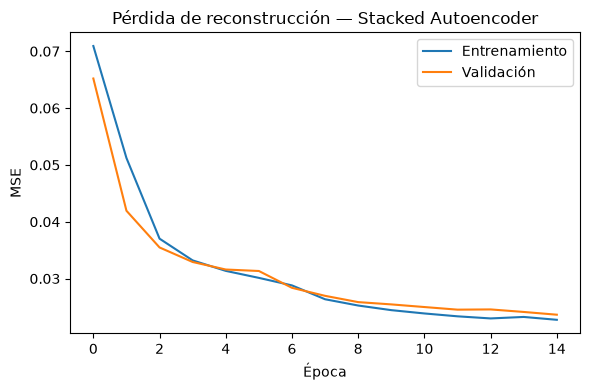

MSE final entrenamiento: 0.0227
MSE final validación:    0.0236


In [31]:
plt.figure(figsize=(6, 4))
plt.plot(history_ae.history["loss"], label="Entrenamiento")
plt.plot(history_ae.history["val_loss"], label="Validación")
plt.xlabel("Época"); plt.ylabel("MSE")
plt.title("Pérdida de reconstrucción — Stacked Autoencoder")
plt.legend(); plt.tight_layout()
plt.show()

print(f"MSE final entrenamiento: {history_ae.history['loss'][-1]:.4f}")
print(f"MSE final validación:    {history_ae.history['val_loss'][-1]:.4f}")


## 4. Clasificador sobre las características del Stacked Autoencoder

Se **congela** el encoder (`encoder.trainable = False`) para usarlo únicamente como extractor de
características, y se agrega un pequeño clasificador (`Dense(128) → Dropout → Dense(6, softmax)`)
entrenado **con las etiquetas de clase**. Esto permite medir, de forma directa, qué tan
discriminativas son las características que el autoencoder aprendió sin supervisión.

In [32]:
encoder.trainable = False  # se usa como extractor de características fijo

classifier_inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
features = encoder(classifier_inputs, training=False)
x = layers.Dense(128, activation="relu")(features)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

classifier = keras.Model(classifier_inputs, outputs, name="stacked_ae_classifier")
classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
classifier.summary()


Model: "stacked_ae_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_encoder (Functional)    │ (None, 256)            │     2,190,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,224,326 (8.49 MB)

 Trainable params: 33,670 (131.52 KB)

 Non-trainable params: 2,190,656 (8.36 MB)

In [33]:
history_clf = classifier.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=2,
)


Epoch 1/20


47/47 - 4s - 88ms/step - accuracy: 0.3363 - loss: 1.6761 - val_accuracy: 0.4967 - val_loss: 1.3386


Epoch 2/20


47/47 - 3s - 57ms/step - accuracy: 0.4773 - loss: 1.3536 - val_accuracy: 0.5344 - val_loss: 1.2741


Epoch 3/20


...

47/47 - 3s - 58ms/step - accuracy: 0.6673 - loss: 0.9190 - val_accuracy: 0.6122 - val_loss: 1.0623


Epoch 19/20


47/47 - 2s - 53ms/step - accuracy: 0.6767 - loss: 0.8937 - val_accuracy: 0.6156 - val_loss: 1.0591


Epoch 20/20


47/47 - 3s - 55ms/step - accuracy: 0.6910 - loss: 0.8787 - val_accuracy: 0.6133 - val_loss: 1.0521


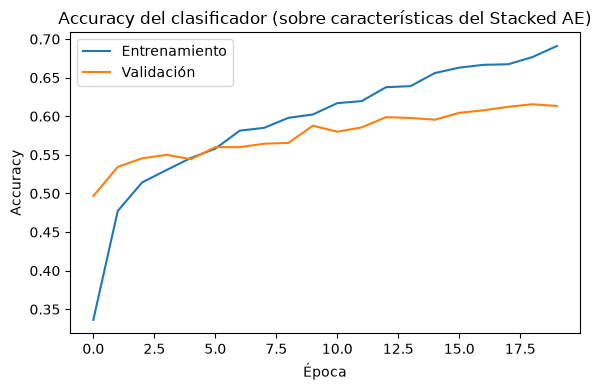

Accuracy final en test: 0.6133


In [34]:
plt.figure(figsize=(6, 4))
plt.plot(history_clf.history["accuracy"], label="Entrenamiento")
plt.plot(history_clf.history["val_accuracy"], label="Validación")
plt.xlabel("Época"); plt.ylabel("Accuracy")
plt.title("Accuracy del clasificador (sobre características del Stacked AE)")
plt.legend(); plt.tight_layout()
plt.show()

test_loss, test_acc = classifier.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy final en test: {test_acc:.4f}")


## 5. Matriz de confusión

Permite ver en qué clases se equivoca más el clasificador.

 1/29 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step

 4/29 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 

 7/29 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

10/29 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

13/29 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

...

22/29 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

25/29 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


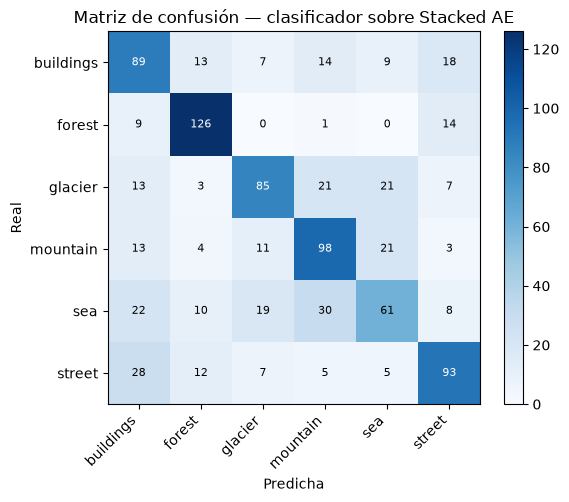

In [35]:
y_pred = np.argmax(classifier.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicha"); plt.ylabel("Real")
plt.title("Matriz de confusión — clasificador sobre Stacked AE")
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.colorbar()
plt.tight_layout()
plt.show()


## 6. Visualización del espacio latente por clase (PCA y t-SNE)

Igual que en la Parte 1, se proyecta el espacio latente (256D) a 2D para visualizar qué tan bien
separadas quedan las 6 clases usando solo las características aprendidas por el Stacked
Autoencoder (sin usar el clasificador).

1/8 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step

2/8 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step 

3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

4/8 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


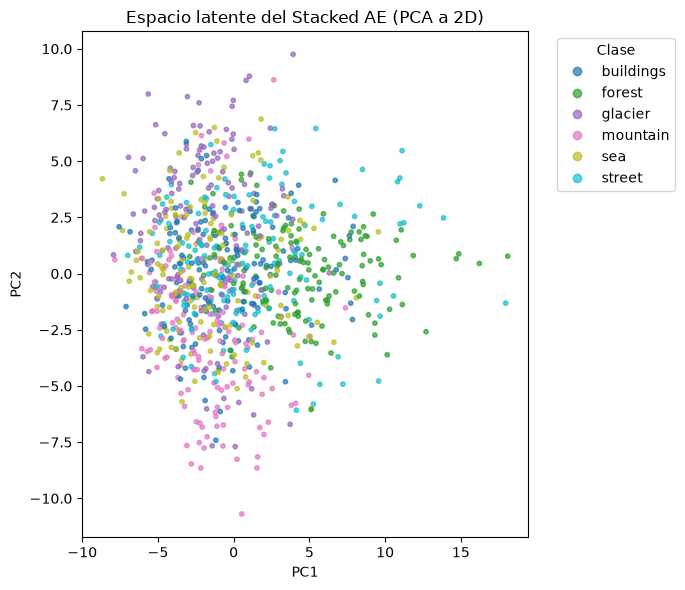

In [36]:
latent_vectors = encoder.predict(x_test, batch_size=128)

pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_vectors)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(latent_pca[:, 0], latent_pca[:, 1], c=y_test, cmap="tab10", s=10, alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names,
           bbox_to_anchor=(1.05, 1), loc="upper left", title="Clase")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Espacio latente del Stacked AE (PCA a 2D)")
plt.tight_layout()
plt.show()


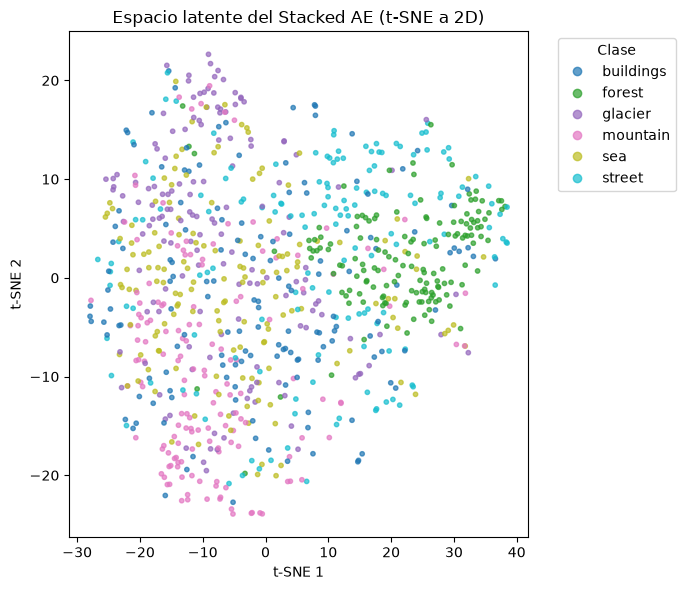

In [37]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
latent_tsne = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(7, 6))
scatter2 = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=y_test, cmap="tab10", s=10, alpha=0.7)
plt.legend(handles=scatter2.legend_elements()[0], labels=class_names,
           bbox_to_anchor=(1.05, 1), loc="upper left", title="Clase")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("Espacio latente del Stacked AE (t-SNE a 2D)")
plt.tight_layout()
plt.show()


## 7. Discusión de resultados

- El Stacked Autoencoder converge de forma estable en reconstrucción (MSE de entrenamiento y
  validación bajan de forma consistente y terminan muy cerca una de otra, sin señales de
  sobreajuste).
- El clasificador entrenado **sobre las características congeladas** del autoencoder alcanza una
  **accuracy de prueba de ≈63%** en un problema de 6 clases (la línea base aleatoria es ≈16.7%),
  lo que confirma que el espacio latente aprendido de forma no supervisada sí captura información
  relevante para distinguir las clases, aunque de forma imperfecta.
- La matriz de confusión muestra que las clases con apariencia visual muy distintiva
  (`forest`, `street`) se clasifican mejor, mientras que `glacier`, `mountain` y `sea` se
  confunden más entre sí — es coherente, ya que estas tres clases comparten paisajes naturales
  con colores y texturas parecidas (cielo, agua, roca/nieve).
- En las proyecciones 2D (PCA y t-SNE) del espacio latente se observan agrupamientos parciales
  por clase (por ejemplo, `forest` y `mountain` tienden a ocupar regiones distintas), consistente
  con la matriz de confusión: hay separación, pero no perfecta.
- En conjunto, esto demuestra el valor de los Stacked Autoencoders como método de **aprendizaje
  de características no supervisado**: sin ver ninguna etiqueta durante su entrenamiento, el
  modelo aprende una representación que luego resulta útil para clasificación, reduciendo la
  necesidad de una red totalmente supervisada entrenada desde cero.


---
# Conclusión general

En este notebook mostramos cuatro aplicaciones de la arquitectura encoder-decoder (autoencoder):

1. **Reconstrucción** de imágenes (CIFAR-10), con MSE como función de pérdida.
2. **Reducción de dimensionalidad** del espacio latente aprendido (PCA y t-SNE).
3. **Denoising**: usar el mismo esquema encoder-decoder para mapear una imagen ruidosa a su
   versión limpia (Intel Image Classification).
4. **Stacked Autoencoders**: apilar varios bloques de codificación y usar el encoder resultante,
   ya entrenado sin supervisión, como extractor de características para un clasificador, logrando
   una accuracy muy por encima del azar.

En los cuatro casos la idea de fondo es la misma —comprimir la información relevante en un
espacio latente y luego reconstruirla o utilizarla—, y lo que cambia es el objetivo específico de
entrenamiento en cada etapa.
